In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import roc_auc_score, cohen_kappa_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("preprocessed_data.csv")

In [4]:
#The structure of the dataset
df.head()

,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,1484,1499,6,22,41410,6.472,113472,628,17532.756490,97.033375,...,0.0,113472,7295988,628,6659,628,1,10,0,5
1,1482,1501,6,41410,22,6.465,24492,370,3788.399072,57.231245,...,0.0,26080,24492,381,370,370,2,1,0,5
2,1486,1501,1,0,0,4.798,2211,4,460.817007,0.833681,...,0.0,28291,3799,385,15,0,3,2,0,3
3,1484,1503,17,57426,1236,595.270,10827817,25627,18189.757590,43.051052,...,0.0,188960322,180776253,157117,153898,30743,60,19,0,6
4,1484,1503,17,48549,1234,595.251,154551644,114704,259641.132900,192.698542,...,0.0,188960322,180776253,157117,153898,122654,60,19,0,6


In [5]:
df.shape
df.columns

Index(['ipv4_src', 'ipv4_dst', 'ip_proto', 'src_port', 'dst_port',
       'flow_duration', 'tot_len_pkts', 'tot_pkts', 'flow_byts_s',
       'flow_pkts_s', 'pkt_size_average', 'fwd_header_len',
       'Byts_max_interval_2s', 'Byts_min_interval_2s', 'Byts_mean_interval_2s',
       'Byts_std_interval_2s', 'Pkts_max_interval_2s', 'Pkts_mean_interval_2s',
       'Pkts_min_interval_2s', 'Pkts_std_interval_2s', 'active_max',
       'active_mean', 'active_min', 'active_std', 'idle_max', 'idle_mean',
       'idle_min', 'idle_std', 'TnBPDstIP', 'TnBPSrcIP', 'TnPPDstIP',
       'TnPPSrcIP', 'TnPPerDport', 'Tn_FlowsPDstIP', 'Tn_FlowsPSrcIP',
       'Attack', 'Category'],
      dtype='str')

In [6]:
#Separating features and target variable
X = df.drop("Category",axis=1)
y = df["Category"]

print("Feature shape:", X.shape)
print("Label Shape:", y.shape)

Feature shape: (221564, 36)
Label Shape: (221564,)


In [7]:
#Since the dataset contains multiple classes but we are focussing only on streaming and non streaming we convert the multi-class-target variable into a binary classfier
#Streaming traffic is labelled as 0
#All other application are labeled as 1

y_binary = y.apply(lambda x: 0 if x==6 else 1)

In [8]:
#Checking the distribution of binary labels
y_binary.value_counts()

Category
1    220077
0      1487
Name: count, dtype: int64

In [9]:
df["Category"].unique()

array([5, 3, 6, 0, 2, 1, 4])

In [10]:
df.groupby("Category").size()

Category
0     53551
1        91
2    164974
3       305
4        23
5      1133
6      1487
dtype: int64

In [23]:
"""
The Hybrid DT–SVM model combines the strengths of Decision Tree and Support Vector Machine classifiers. 
In this hybrid approach, the Decision Tree acts as the base learner and captures non-linear patterns in 
the dataset through hierarchical feature splitting. The predictions generated by the Decision Tree are 
then passed to a Support Vector Machine as the final estimator using a stacking architecture.

The SVM refines the decision boundary by learning from the outputs of the Decision Tree, allowing the 
model to improve classification performance. This hybrid approach leverages the interpretability and 
feature partitioning ability of Decision Trees along with the strong margin-based optimization of SVM.  

"""

from sklearn.ensemble import StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

hybrid_dt_svm = StackingClassifier(
    estimators=[
        ("dt", DecisionTreeClassifier(random_state=42))
    ],
    final_estimator=LinearSVC(random_state=42)
)

hybrid_knn_svm = StackingClassifier(
    estimators=[
        ("knn", KNeighborsClassifier(n_neighbors=5, algorithm="kd_tree", n_jobs=-1))
    ],
    final_estimator=LinearSVC(random_state=42),
    cv=2,
    n_jobs=-1
)

In [15]:
models = {
    "SVM": LinearSVC(random_state=42),
    "DT": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),

    "Hybrid DT-SVM": hybrid_dt_svm,
    "Hybrid KNN-SVM": hybrid_knn_svm
}

In [16]:

#Now we train models on different split rations and store the results in a dictionary 

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import joblib, os

# folder to persist models
os.makedirs("saved_models", exist_ok=True)

splits = {
    "70-30": 0.30,
    "60-40": 0.40,
    "50-50": 0.50,
    "30-70": 0.70
}

# dictionary: results_by_split[split][model] = metrics
results_by_split = {}

# optional flat list for dataframe later
results_all = []

# dictionary to store trained models in memory
trained_models = {}

for split_name, test_size in splits.items():

    print("\n" + "="*60)
    print(f"Running experiment for split {split_name}")
    print("="*60)

    # store models for this split
    trained_models[split_name] = {}

    # train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_binary,
        test_size=test_size,
        random_state=42,
        stratify=y_binary
    )

    # SMOTE on training data only
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # results dict for this split
    results_by_split[split_name] = {}

    for name, model in models.items():

        print(f"\nTraining {name}...")

        model.fit(X_train_resampled, y_train_resampled)

        # store trained model
        trained_models[split_name][name] = model

        # save model to disk
        joblib.dump(model, f"saved_models/{name}_{split_name}.pkl")

        # predictions
        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:,1]
        else:
            y_score = model.decision_function(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        kappa = cohen_kappa_score(y_test, y_pred)
        roc = roc_auc_score(y_test, y_score)

        cm = confusion_matrix(y_test, y_pred)

        print("Confusion Matrix:")
        print(cm)

        # store nicely in dictionary
        results_by_split[split_name][name] = {
            "Accuracy": accuracy,
            "F1 Score": f1,
            "Kappa Score": kappa,
            "ROC AUC": roc,
            "Confusion Matrix": cm
        }

        # also store flat format for dataframe
        results_all.append({
            "Split": split_name,
            "Model": name,
            "Accuracy": accuracy,
            "F1 Score": f1,
            "Kappa Score": kappa,
            "ROC AUC": roc
        })


Running experiment for split 70-30

Training SVM...
Confusion Matrix:
[[  288   158]
 [ 4652 61372]]

Training DT...
Confusion Matrix:
[[  446     0]
 [    0 66024]]

Training KNN...
Confusion Matrix:
[[  431    15]
 [   31 65993]]

Training XGBoost...
Confusion Matrix:
[[  446     0]
 [    0 66024]]

Training Hybrid DT-SVM...
Confusion Matrix:
[[  446     0]
 [    0 66024]]

Training Hybrid KNN-SVM...
Confusion Matrix:
[[  431    15]
 [   31 65993]]

Running experiment for split 60-40

Training SVM...
Confusion Matrix:
[[  398   197]
 [ 5700 82331]]

Training DT...
Confusion Matrix:
[[  593     2]
 [    0 88031]]

Training KNN...
Confusion Matrix:
[[  578    17]
 [   66 87965]]

Training XGBoost...
Confusion Matrix:
[[  593     2]
 [    0 88031]]

Training Hybrid DT-SVM...
Confusion Matrix:
[[  593     2]
 [    0 88031]]

Training Hybrid KNN-SVM...
Confusion Matrix:
[[  578    17]
 [   66 87965]]

Running experiment for split 50-50

Training SVM...
Confusion Matrix:
[[   498    246]


In [17]:
accuracy_table = (
    pd.DataFrame(results_all)
    .assign(Test_values=lambda df: "Test = " + df["Split"].str.split("-").str[1] + "%")
    .pivot(index="Test_values", columns="Model", values="Accuracy")
    .mul(100)
    .round(2)
)

accuracy_table

Model,DT,Hybrid DT-SVM,Hybrid KNN-SVM,KNN,SVM,XGBoost
Test_values,,,,,,
Test = 30%,100.0,100.0,99.93,99.93,92.76,100.0
Test = 40%,100.0,100.0,99.91,99.91,93.35,100.0
Test = 50%,100.0,100.0,99.89,99.89,94.46,100.0
Test = 70%,100.0,100.0,99.83,99.83,92.98,100.0


In [18]:
import pandas as pd
import os

# convert results list to dataframe
results_df = pd.DataFrame(results_all)

# create folder if it doesn't exist
os.makedirs("results", exist_ok=True)

# save to csv
results_df.to_csv("results/model_results.csv", index=False)

print("Results saved to results/model_results.csv")

Results saved to results/model_results.csv


In [20]:
results_df = pd.read_csv("results/model_results.csv")
results_df

,Split,Model,Accuracy,F1 Score,Kappa Score,ROC AUC
0,70-30,SVM,0.927637,0.962290,0.095815,0.935531
1,70-30,DT,1.000000,1.000000,1.000000,1.000000
2,70-30,KNN,0.999308,0.999652,0.948991,0.985358
3,70-30,XGBoost,1.000000,1.000000,1.000000,1.000000
4,70-30,Hybrid DT-SVM,1.000000,1.000000,1.000000,1.000000
5,70-30,Hybrid KNN-SVM,0.999308,0.999652,0.948991,0.985358
6,60-40,SVM,0.933462,0.965425,0.108018,0.928658
7,60-40,DT,0.999977,0.999989,0.998305,0.998319
8,60-40,KNN,0.999063,0.999528,0.932540,0.987299
9,60-40,XGBoost,0.999977,0.999989,0.998305,0.999991


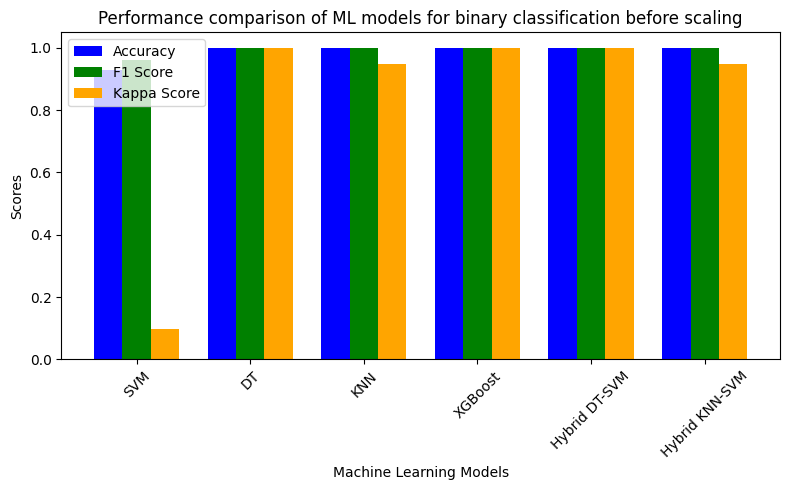

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load results
results_df = pd.read_csv("results/model_results.csv")

# take one split (paper figure usually shows one split like 70-30)
df = results_df[results_df["Split"] == "70-30"]

models = df["Model"]
accuracy = df["Accuracy"]
f1 = df["F1 Score"]
kappa = df["Kappa Score"]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, accuracy, width, label="Accuracy", color="blue")
plt.bar(x, f1, width, label="F1 Score", color="green")
plt.bar(x + width, kappa, width, label="Kappa Score", color="orange")

plt.xticks(x, models, rotation=45)
plt.ylabel("Scores")
plt.xlabel("Machine Learning Models")
plt.title("Performance comparison of ML models for binary classification before scaling")

plt.legend()
plt.tight_layout()
plt.show()

In [24]:
#The kappa score of SVM is now because of the high imbalance in testing dataset
